In [35]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Impostazione del seed per la riproducibilità
random.seed(42)
np.random.seed(42)

num_cases = 100  # Numero di casi da generare
activities = ['A', 'B', 'C', 'D', 'E']  # Attività del processo
base_time = datetime(2025, 1, 1, 8, 0, 0)  # Tempo di partenza di base

events = []  # Lista per memorizzare le righe del dataset

for case in range(1, num_cases + 1):
    case_id = f"case_{case}"
    # Assegno la proprietà "Property 1" rispettando la distribuzione: 45% valore 1, 55% valore 0
    prop = 1 if random.random() < 0.45 else 0
    case_start = base_time + timedelta(minutes=random.randint(0, 60 * 24))
    current_time = case_start
    occurrence_id = 1  # Occurrence id incrementale per ciascuna attività nel caso

    # Per A, B, C: durate tra 30 e 120 minuti, gap tra 5 e 20 minuti
    for act in activities[:3]:
        start_time = current_time
        duration = timedelta(minutes=random.randint(30, 120))
        end_time = start_time + duration
        events.append({
            'case_id': case_id,
            'occurrence_id': occurrence_id,
            'activity': act,
            'start_time': start_time,
            'end_time': end_time,
            'property1': prop  # verrà rinominata in seguito
        })
        occurrence_id += 1
        # Aggiorna il tempo: gap tra 5 e 20 minuti
        current_time = end_time + timedelta(minutes=random.randint(5, 20))

    # Per D: in base a prop
    if prop == 1:
        # Regola soddisfatta: D deve comparire entro 48 ore
        # Impostiamo D tra 5 e 30 minuti dopo C, assicurandoci che non superi le 48 ore dalla partenza
        gap = timedelta(minutes=random.randint(5, 30))
        d_time = current_time + gap
        # Se per caso d_time supera 48 ore dalla partenza, lo fissiamo a case_start + 47 ore e 59 minuti
        if (d_time - case_start).total_seconds() > 48 * 3600:
            d_time = case_start + timedelta(hours=47, minutes=59)
        d_duration = timedelta(minutes=random.randint(30, 120))
    else:
        # Regola non soddisfatta: D deve comparire dopo 48 ore, ma non troppo distante
        # Impostiamo D tra 48 e 60 ore dalla partenza
        d_time = case_start + timedelta(hours=random.randint(48, 60))
        # Se il current_time è già oltre d_time, allora impostiamo D appena dopo current_time
        if d_time < current_time:
            d_time = current_time + timedelta(minutes=random.randint(5, 20))
        d_duration = timedelta(minutes=random.randint(30, 120))
    
    d_start = d_time
    d_end = d_start + d_duration
    events.append({
        'case_id': case_id,
        'occurrence_id': occurrence_id,
        'activity': 'D',
        'start_time': d_start,
        'end_time': d_end,
        'property1': prop
    })
    occurrence_id += 1
    current_time = d_end + timedelta(minutes=random.randint(5, 20))

    # Per E: come le altre attività normali
    start_time = current_time
    duration = timedelta(minutes=random.randint(30, 120))
    end_time = start_time + duration
    events.append({
        'case_id': case_id,
        'occurrence_id': occurrence_id,
        'activity': 'E',
        'start_time': start_time,
        'end_time': end_time,
        'property1': prop
    })
    occurrence_id += 1

# Creazione del DataFrame a partire dalla lista degli eventi
df = pd.DataFrame(events)

# Aggiunta di noise sui timestamp: jitter casuale compreso tra -3 e +3 minuti
noisy_start = []
noisy_end = []
for idx, row in df.iterrows():
    jitter_start = timedelta(minutes=random.randint(-3, 3))
    jitter_end = timedelta(minutes=random.randint(-3, 3))
    new_start = row['start_time'] + jitter_start
    new_end = row['end_time'] + jitter_end
    if new_start >= new_end:
        new_end = new_start + timedelta(minutes=1)
    noisy_start.append(new_start)
    noisy_end.append(new_end)

df['start_time'] = noisy_start
df['end_time'] = noisy_end

# Introduzione di errori di sequenza
# La variabile sequence_noise_level controlla la probabilità che un caso subisca errori di sequenza
sequence_noise_level = 0.2  # ad esempio, il 20% dei casi verrà modificato

# Applichiamo il noise caso per caso
cases = df['case_id'].unique()
noisy_cases = []
for c in cases:
    case_df = df[df['case_id'] == c].copy()
    # Con probabilità sequence_noise_level introduciamo un errore nella sequenza
    if random.random() < sequence_noise_level:
        # Decidiamo casualmente se scambiare due eventi (ordine invertito) o duplicarne uno (azione ripetuta)
        if random.random() < 0.5:
            # Errore di inversione: scambiamo due righe a caso
            if len(case_df) >= 2:
                indices = case_df.index.tolist()
                i1, i2 = random.sample(indices, 2)
                temp = case_df.loc[i1].copy()
                case_df.loc[i1] = case_df.loc[i2]
                case_df.loc[i2] = temp
        else:
            # Errore di duplicazione: duplico un evento scelto casualmente e lo inserisco in una posizione casuale
            indices = case_df.index.tolist()
            dup_idx = random.choice(indices)
            duplicate_row = case_df.loc[dup_idx].copy()
            # Aggiungiamo un piccolo jitter anche al duplicato per renderlo leggermente differente
            duplicate_row['start_time'] = duplicate_row['start_time'] + timedelta(minutes=random.randint(-1, 1))
            duplicate_row['end_time'] = duplicate_row['end_time'] + timedelta(minutes=random.randint(-1, 1))
            # Utilizziamo pd.concat per aggiungere il duplicato
            case_df = pd.concat([case_df, pd.DataFrame([duplicate_row])], ignore_index=True)
    noisy_cases.append(case_df)

df_noisy = pd.concat(noisy_cases, ignore_index=True)

# Non riordiniamo il DataFrame finale per preservare il noise introdotto nelle sequenze

# Riposizionamento della colonna "property1" in ultima posizione e rinomina in "Property 1"
df_noisy = df_noisy[['case_id', 'occurrence_id', 'activity', 'start_time', 'end_time', 'property1']]
df_noisy.rename(columns={'property1': 'Property 1'}, inplace=True)

# Calcolo delle statistiche sul log risultante
total_traces = df_noisy['case_id'].nunique()
total_events = len(df_noisy)
# Per ciascun caso, la durata viene calcolata come la differenza tra il minimo start_time e il massimo end_time
case_duration = df_noisy.groupby('case_id').agg({'start_time': 'min', 'end_time': 'max'})
case_duration['duration'] = case_duration['end_time'] - case_duration['start_time']
avg_duration = case_duration['duration'].mean()
trace_property_counts = df_noisy.groupby('case_id')['Property 1'].first().value_counts()

print("Tracce totali:", total_traces)
print("Eventi totali:", total_events)
print("Durata media per caso:", avg_duration)
print("Tracce con Property 1 = 1:", trace_property_counts.get(1, 0))
print("Tracce con Property 1 = 0:", trace_property_counts.get(0, 0))

# Conversione dei timestamp in formato stringa
df_noisy['start_time'] = df_noisy['start_time'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_noisy['end_time'] = df_noisy['end_time'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Suddivisione in train e test set basata sui case_id
unique_cases = df_noisy['case_id'].unique()
train_cases = set(np.random.choice(unique_cases, size=int(0.8 * len(unique_cases)), replace=False))
df_train = df_noisy[df_noisy['case_id'].isin(train_cases)]
df_test = df_noisy[~df_noisy['case_id'].isin(train_cases)]

df_train.to_csv("train_synt.csv", index=False)
df_test.to_csv("test_synt.csv", index=False)

print("Dataset generato e salvato in train_synt.csv e test_synt.csv")

Tracce totali: 100
Eventi totali: 511
Durata media per caso: 1 days 14:48:31.200000
Tracce con Property 1 = 1: 37
Tracce con Property 1 = 0: 63
Dataset generato e salvato in train_synt.csv e test_synt.csv


/var/folders/9j/10v9ngt92ts7snck5_jqsz1m0000gn/T/ipykernel_7944/32262448.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('case_id', sort=False).apply(
/var/folders/9j/10v9ngt92ts7snck5_jqsz1m0000gn/T/ipykernel_7944/32262448.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('case_id', sort=False).apply(


ConvLSTMWithTime(
  (embedding): Embedding(6, 128, padding_idx=0)
  (time_linear): Linear(in_features=1, out_features=128, bias=True)
  (conv1d): Conv1d(256, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (lstm): LSTM(64, 100, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 1/100 - Train Loss: 0.7005 - Val Loss: 0.7071
Epoch 2/100 - Train Loss: 0.7010 - Val Loss: 0.6560
Epoch 3/100 - Train Loss: 0.6517 - Val Loss: 0.6018
Epoch 4/100 - Train Loss: 0.6003 - Val Loss: 0.5896
Epoch 5/100 - Train Loss: 0.5777 - Val Loss: 0.5841
Epoch 6/100 - Train Loss: 0.5735 - Val Loss: 0.5644
Epoch 7/100 - Train Loss: 0.5640 - Val Loss: 0.5635
Epoch 8/100 - Train Loss: 0.5636 - Val Loss: 0.5306
Epoch 9/100 - Train Loss: 0.5258 - Val Loss: 0.5229
Epoch 10/100 - Train Loss: 0.5123 - Val Loss: 0.5121
Epoch 11/100 - Train Loss: 0.4961 - Val Loss: 0.5183
Epoch 12/100 - Train Loss: 0.5063 - Val Loss: 0.5353
Epoch 13/100 - Train

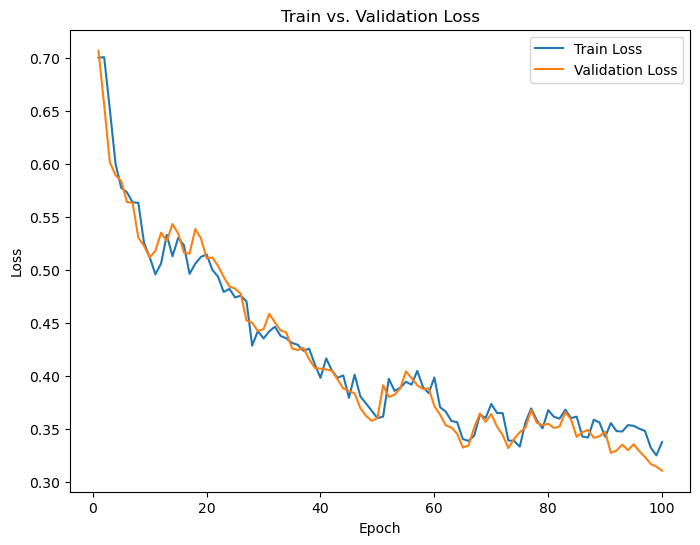

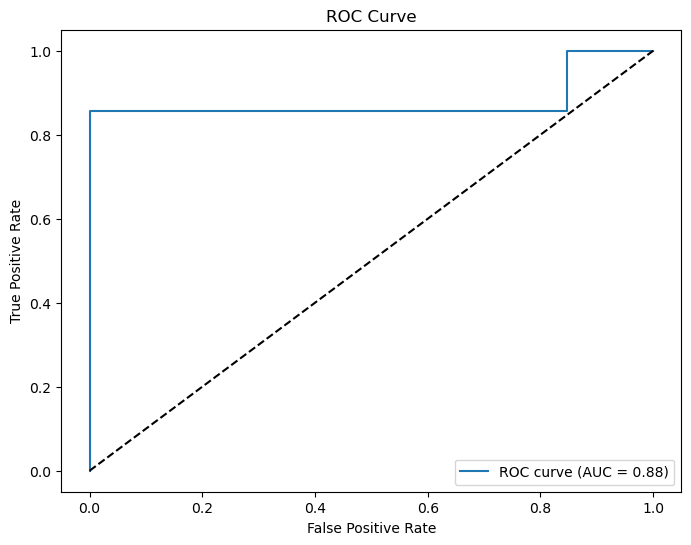

AUC (timestep level): 0.879
Tracce riconosciute correttamente: 19/20


In [36]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from datetime import datetime

# 1) Lettura dei file CSV con parse_dates per gestire i timestamp
train_df = pd.read_csv('train_synt.csv', parse_dates=['start_time', 'end_time'])
test_df = pd.read_csv('test_synt.csv', parse_dates=['start_time', 'end_time'])

# 2) Ordiniamo gli eventi per case_id e occurrence_id, e calcoliamo i delta temporali in secondi
def preprocess_df(df):
    df = df.sort_values(['case_id', 'occurrence_id']).copy()
    df['delta_time'] = 0.0
    cases = df['case_id'].unique()
    for c in cases:
        mask = (df['case_id'] == c)
        case_data = df.loc[mask].sort_values('occurrence_id')
        start_times = case_data['start_time'].tolist()
        deltas = [0.0]
        for i in range(1, len(start_times)):
            diff_sec = (start_times[i] - start_times[i-1]).total_seconds()
            if diff_sec < 0:
                diff_sec = 0.0
            deltas.append(diff_sec)
        df.loc[case_data.index, 'delta_time'] = deltas
    return df

train_df = preprocess_df(train_df)
test_df = preprocess_df(test_df)

# 3) Raggruppamento: per ogni caso otteniamo le liste di (attività, delta_time) e le etichette dinamiche
# La regola: "A deve accadere insieme a D entro 48h"
T_threshold = 48 * 3600  # 48 ore in secondi

# MODIFICA: funzione compute_dynamic_label aggiornata
def compute_dynamic_label(group):
    cum_times = group['delta_time'].cumsum()  # il primo evento ha cum_time = 0
    labels = []
    d_found = False
    d_time = None
    for t, act in zip(cum_times, group['activity']):
        # Se incontriamo "D" per la prima volta, salviamo il tempo in cui compare
        if act == 'D' and not d_found:
            d_found = True
            d_time = t
        if d_found:
            # Se "D" è comparso entro il threshold, la label diventa 1, altrimenti 0
            if d_time <= T_threshold:
                labels.append(1.0)
            else:
                labels.append(0.0)
        else:
            # Fino a "D": decresce linearmente da 1 a 0; se si supera T_threshold, rimane a 0
            labels.append(max(0.0, 1.0 - t / T_threshold))
    return labels

def group_sequences(df):
    grouped = df.groupby('case_id', sort=False).apply(
        lambda group: pd.Series({
            'activity': group['activity'].tolist(),
            'delta_time': group['delta_time'].tolist(),
            'label': compute_dynamic_label(group)
        })
    ).reset_index()
    return grouped

train_grouped = group_sequences(train_df)
test_grouped = group_sequences(test_df)

train_activities = train_grouped['activity'].tolist()
train_deltas = train_grouped['delta_time'].tolist()
train_labels = train_grouped['label'].tolist()

test_activities = test_grouped['activity'].tolist()
test_deltas = test_grouped['delta_time'].tolist()
test_labels = test_grouped['label'].tolist()

# 4) Creazione del vocabolario delle attività
vocab = {}
for seq in train_activities:
    for token in seq:
        if token not in vocab:
            vocab[token] = len(vocab) + 1  # Indici da 1 a N, 0 riservato al padding
vocab_size = len(vocab) + 1

def tokenize_sequence(seq, vocab):
    return [vocab.get(token, 0) for token in seq]

X_train_acts = [tokenize_sequence(seq, vocab) for seq in train_activities]
X_test_acts = [tokenize_sequence(seq, vocab) for seq in test_activities]

# 5) Padding left per attività, delta_time e label
def pad_sequences(sequences, max_len, pad_value):
    padded = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = [pad_value] * (max_len - len(seq)) + seq
        else:
            padded_seq = seq[-max_len:]
        padded.append(padded_seq)
    return np.array(padded)

max_seq_length = max(
    max(len(seq) for seq in X_train_acts),
    max(len(seq) for seq in X_test_acts)
)

X_train_acts_padded = pad_sequences(X_train_acts, max_seq_length, pad_value=0)
X_test_acts_padded = pad_sequences(X_test_acts, max_seq_length, pad_value=0)

X_train_time_padded = pad_sequences(train_deltas, max_seq_length, pad_value=0.0)
X_test_time_padded = pad_sequences(test_deltas, max_seq_length, pad_value=0.0)

y_train_padded = pad_sequences(train_labels, max_seq_length, pad_value=-1)
y_test_padded = pad_sequences(test_labels, max_seq_length, pad_value=-1)

# 6) Dataset custom che restituisce (X_acts, X_time, y, mask)
class ProcessLogTimeDataset(Dataset):
    def __init__(self, X_act, X_time, y):
        self.X_act = torch.tensor(X_act, dtype=torch.long)
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.mask = (self.y != -1).float()
        self.y[self.y == -1] = 0.0

    def __len__(self):
        return len(self.X_act)

    def __getitem__(self, idx):
        return self.X_act[idx], self.X_time[idx], self.y[idx], self.mask[idx]

train_dataset = ProcessLogTimeDataset(X_train_acts_padded, X_train_time_padded, y_train_padded)
test_dataset = ProcessLogTimeDataset(X_test_acts_padded, X_test_time_padded, y_test_padded)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 7) Definizione del modello che combina embedding attività e tempo
class ConvLSTMWithTime(nn.Module):
    def __init__(self, vocab_size, embed_dim, conv_channels, kernel_size, lstm_hidden, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.time_linear = nn.Linear(1, embed_dim)
        self.conv1d = nn.Conv1d(in_channels=embed_dim*2,
                                out_channels=conv_channels,
                                kernel_size=kernel_size,
                                padding=kernel_size//2)
        self.lstm = nn.LSTM(input_size=conv_channels, hidden_size=lstm_hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)
    
    def forward(self, x_act, x_time):
        emb_act = self.embedding(x_act)                   # [batch, seq_len, embed_dim]
        emb_time = self.time_linear(x_time.unsqueeze(-1))   # [batch, seq_len, embed_dim]
        emb_cat = torch.cat([emb_act, emb_time], dim=-1)    # [batch, seq_len, 2*embed_dim]
        emb_cat = emb_cat.transpose(1, 2)                   # [batch, 2*embed_dim, seq_len]
        conv_out = F.relu(self.conv1d(emb_cat))             # [batch, conv_channels, seq_len]
        conv_out = conv_out.transpose(1, 2)                 # [batch, seq_len, conv_channels]
        lstm_out, _ = self.lstm(conv_out)                   # [batch, seq_len, lstm_hidden]
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)                          # [batch, seq_len, 1]
        probs = torch.sigmoid(logits)                       # [batch, seq_len, 1]
        return probs

embed_dim = 128
conv_channels = 64
kernel_size = 3
lstm_hidden = 100
dropout_rate = 0.5

model = ConvLSTMWithTime(vocab_size, embed_dim, conv_channels, kernel_size, lstm_hidden, dropout_rate)
print(model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# 8) Funzioni di training e evaluation
train_losses = []
val_losses = []

def train_epoch(model, loader, optimizer):
    model.train()
    epoch_loss = 0.0
    total_tokens = 0
    for X_act_batch, X_time_batch, y_batch, mask_batch in loader:
        X_act_batch = X_act_batch.to(device)
        X_time_batch = X_time_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_act_batch, X_time_batch)  # [batch, seq_len, 1]
        loss = F.binary_cross_entropy(outputs, y_batch.unsqueeze(-1), reduction='none')
        loss = loss * mask_batch.unsqueeze(-1)
        batch_loss = loss.sum() / mask_batch.sum()
        batch_loss.backward()
        optimizer.step()

        epoch_loss += batch_loss.item() * mask_batch.sum().item()
        total_tokens += mask_batch.sum().item()
    return epoch_loss / total_tokens

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for X_act_batch, X_time_batch, y_batch, mask_batch in loader:
            X_act_batch = X_act_batch.to(device)
            X_time_batch = X_time_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            outputs = model(X_act_batch, X_time_batch)
            loss = F.binary_cross_entropy(outputs, y_batch.unsqueeze(-1), reduction='none')
            loss = loss * mask_batch.unsqueeze(-1)
            total_loss += loss.sum().item()
            total_tokens += mask_batch.sum().item()
    return total_loss / total_tokens

# 9) Training
num_epochs = 100
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss = evaluate(model, test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs. Validation Loss')
plt.legend()
plt.show()

# 10) Valutazione finale: ROC AUC e conteggio tracce riconosciute
model.eval()
all_targets = []       # a livello timestep (non usati per l’AUC finale)
all_predictions = []
trace_targets = []     # a livello traccia, last timestep
trace_predictions = []

with torch.no_grad():
    for X_act_batch, X_time_batch, y_batch, mask_batch in test_loader:
        X_act_batch = X_act_batch.to(device)
        X_time_batch = X_time_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        outputs = model(X_act_batch, X_time_batch)  # [batch, seq_len, 1]
        outputs = outputs.squeeze(-1)               # [batch, seq_len]
        valid_indices = mask_batch.bool()

        all_targets.extend(y_batch[valid_indices].cpu().numpy())
        all_predictions.extend(outputs[valid_indices].cpu().numpy())
        
        for i in range(X_act_batch.size(0)):
            valid_timesteps = mask_batch[i].nonzero(as_tuple=False).squeeze()
            if valid_timesteps.numel() == 0:
                continue
            last_index = valid_timesteps[-1].item()
            trace_targets.append(y_batch[i, last_index].item())
            trace_predictions.append(outputs[i, last_index].item())

# Binarizziamo i target a livello traccia:
# Se "D" è avvenuto entro il threshold, la label è 1, altrimenti 0.
trace_targets_bin = [1 if t == 1.0 else 0 for t in trace_targets]

if len(set(trace_targets_bin)) < 2:
    print("ROC AUC non definito: sono presenti target di una sola classe.")
else:
    auc = roc_auc_score(trace_targets_bin, trace_predictions)
    fpr, tpr, thresholds = roc_curve(trace_targets_bin, trace_predictions)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

    print(f"AUC (timestep level): {auc:.3f}")

trace_predictions_bin = [1 if p > 0.5 else 0 for p in trace_predictions]
correct_traces = sum(1 for pred, true in zip(trace_predictions_bin, trace_targets_bin) if pred == true)
total_traces = len(trace_targets_bin)

print(f"Tracce riconosciute correttamente: {correct_traces}/{total_traces}")

Traccia selezionata: case_id = case_85, etichetta reale (Property 1) = 0
Evento 1: A, tempo = 0.00 sec (0h 0m 0s)
Evento 2: B, tempo = 3720.00 sec (1h 2m 0s)
Evento 3: C, tempo = 6120.00 sec (1h 42m 0s)
Evento 4: D, tempo = 176400.00 sec (49h 0m 0s)
Evento 5: E, tempo = 182640.00 sec (50h 44m 0s)
Durata totale del caso: 182640.00 sec

Predizioni nel tempo:
Al tempo 0.0 min (T=0 sec): eventi=['A'], delta=[0.], pred=0.9675
Al tempo 1.0 min (T=60 sec): eventi=['A'], delta=[60.], pred=0.5174
Al tempo 2.0 min (T=120 sec): eventi=['A'], delta=[120.], pred=0.4982
Al tempo 3.0 min (T=180 sec): eventi=['A'], delta=[180.], pred=0.4906
Al tempo 4.0 min (T=240 sec): eventi=['A'], delta=[240.], pred=0.4868
Al tempo 5.0 min (T=300 sec): eventi=['A'], delta=[300.], pred=0.4845
Al tempo 6.0 min (T=360 sec): eventi=['A'], delta=[360.], pred=0.4830
Al tempo 7.0 min (T=420 sec): eventi=['A'], delta=[420.], pred=0.4819
Al tempo 8.0 min (T=480 sec): eventi=['A'], delta=[480.], pred=0.4812
Al tempo 9.0 min 

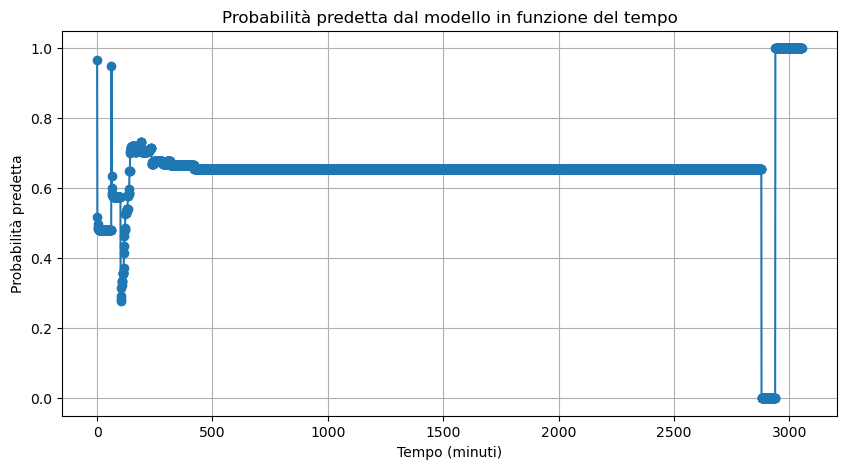

In [37]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from datetime import datetime
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Carichiamo il file test_synt.csv, interpretando le colonne di tempo come datetime
test_df = pd.read_csv('test_synt.csv', parse_dates=['start_time', 'end_time'])

# Funzione per estrarre le informazioni della traccia
def get_trace_info(case_id, df):
    df = df.sort_values('occurrence_id')
    return {
        'case_id': case_id,
        'activities': df['activity'].tolist(),
        'start_times': df['start_time'].tolist(),
        'property': df['Property 1'].iloc[0]  # etichetta reale
    }

# Raggruppiamo per case_id e creiamo la lista di tracce
test_grouped = test_df.groupby('case_id')

traces = []
for cid, group in test_grouped:
    info = get_trace_info(cid, group)
    traces.append(info)

# Selezione di una traccia casuale che abbia almeno 2 eventi e durata >= 5 minuti (300 sec)
min_duration = 300  # 5 minuti
selected_trace_info = None

while True:
    candidate = random.choice(traces)
    start_times = candidate['start_times']
    t0 = start_times[0]
    # Tempi cumulati in secondi dal primo evento
    cumulative_times = [(t - t0).total_seconds() for t in start_times]
    actual_length = len(candidate['activities'])
    total_duration = cumulative_times[-1] if actual_length > 0 else 0.0
    if actual_length >= 2 and total_duration >= min_duration:
        selected_trace_info = candidate
        break

print(f"Traccia selezionata: case_id = {selected_trace_info['case_id']}, "
      f"etichetta reale (Property 1) = {selected_trace_info['property']}")

# Mapping inverso delle attività (dizionario idx2act)
# Se nel training hai definito "vocab = {attività: indice}", costruiamo idx2act:
idx2act = {v: k for k, v in vocab.items()}

activities = selected_trace_info['activities']
start_times = selected_trace_info['start_times']
t0 = start_times[0]
cumulative_times = [(t - t0).total_seconds() for t in start_times]

# Stampa degli eventi della traccia
for i, (act, t_sec) in enumerate(zip(activities, cumulative_times)):
    hrs = int(t_sec // 3600)
    mins = int((t_sec % 3600) // 60)
    secs = int(t_sec % 60)
    print(f"Evento {i+1}: {act}, tempo = {t_sec:.2f} sec ({hrs}h {mins}m {secs}s)")
print(f"Durata totale del caso: {cumulative_times[-1]:.2f} sec")

# Definiamo gli intervalli temporali: da 0 a total_duration+600 sec, ogni 60 sec
total_duration = cumulative_times[-1]
max_T = total_duration + 600
time_points = np.arange(0, max_T + 60, 60)  # in secondi

predictions = []

# Soglia di 48 ore in secondi (48*3600)
T_threshold = 48 * 3600

model = model.to(device)
model.eval()

print("\nPredizioni nel tempo:")
for T in time_points:
    # Determiniamo quanti eventi sono avvenuti entro il tempo T
    prefix_length = np.searchsorted(cumulative_times, T, side='right')
    prefix_length = max(prefix_length, 1)  # almeno 1 evento
    if prefix_length > len(activities):
        prefix_length = len(activities)
    
    prefix_activities = activities[:prefix_length]
    
    # Costruiamo i delta temporali per il prefisso:
    # - Se c'è un solo evento, il delta sarà T (ovvero il tempo trascorso dall'inizio)
    # - Altrimenti, per gli eventi da 2 a prefix_length-1 usiamo i delta fissi,
    #   e per l'ultimo evento usiamo: T - tempo dell'ultimo evento registrato.
    if prefix_length == 1:
        prefix_deltas = [T]
    else:
        fixed_deltas = [cumulative_times[i] - cumulative_times[i-1] for i in range(1, prefix_length)]
        # L'ultimo delta viene aggiornato in base a T (invece di usare il valore fisso)
        fixed_deltas[-1] = T - cumulative_times[prefix_length-1]
        prefix_deltas = [0.0] + fixed_deltas  # il primo evento ha delta 0
    
    # Convertiamo le attività in indici usando il vocabolario
    prefix_indices = [vocab.get(act, 0) for act in prefix_activities]
    
    # Controlli "hard-coded":
    # Se D è presente (cioè la formula è vera) => output forzato a 1.0
    # Se sono passate 48h senza D => output forzato a 0.0
    if 'D' in prefix_activities:
        pred = 1.0
    elif T >= T_threshold:
        pred = 0.0
    else:
        # Altrimenti, usiamo il modello per la predizione
        x_act_tensor = torch.tensor(prefix_indices, dtype=torch.long).unsqueeze(0).to(device)
        x_time_tensor = torch.tensor(prefix_deltas, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x_act_tensor, x_time_tensor)  # shape: [1, seq_len, 1]
            pred = out[0, -1, 0].item()
    
    predictions.append(pred)
    print(f"Al tempo {T/60:.1f} min (T={T:.0f} sec): "
          f"eventi={prefix_activities}, delta={np.around(prefix_deltas,2)}, pred={pred:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(time_points / 60, predictions, marker='o', linestyle='-')
plt.xlabel("Tempo (minuti)")
plt.ylabel("Probabilità predetta")
plt.title("Probabilità predetta dal modello in funzione del tempo")
plt.grid(True)
plt.show()